--- Clustering Performance (K-Means) ---
Accuracy : 0.9051
Precision: 0.9040
Recall   : 0.9496
F1-Score : 0.9262


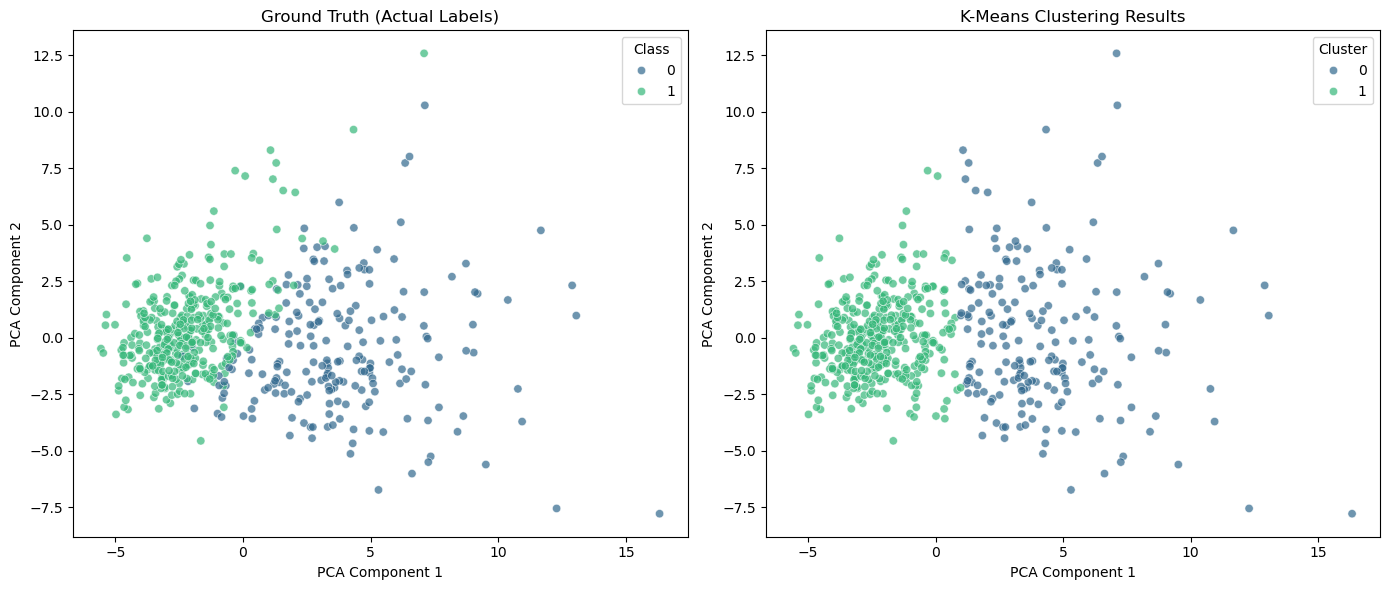

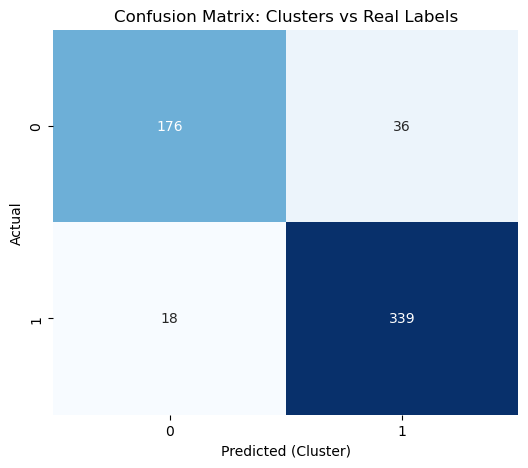

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0: Malignant, 1: Benign

# 2. Preprocessing (Scaling is crucial for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Clustering Model (Simple K-Means)
# We choose 2 clusters because we know there are 2 types of cancer in ground truth
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 4. Label Correction
# K-Means assigns random IDs (0 or 1). We align them with the ground truth (y).
# If the correlation is negative or accuracy is low, we flip the cluster labels.
# This is a heuristic to calculate classification metrics on clustering results.
labels_pred = clusters.copy()
if accuracy_score(y, labels_pred) < 0.5:
    labels_pred = 1 - labels_pred  # Flip 0 to 1 and 1 to 0

# 5. Evaluation Metrics
acc = accuracy_score(y, labels_pred)
prec = precision_score(y, labels_pred)
rec = recall_score(y, labels_pred)
f1 = f1_score(y, labels_pred)

print("--- Clustering Performance (K-Means) ---")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

# 6. Visualization
# We use PCA to reduce dimensions to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

# Plot 1: Actual Labels
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='viridis', alpha=0.7)
plt.title('Ground Truth (Actual Labels)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Class')

# Plot 2: K-Means Clusters
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_pred, palette='viridis', alpha=0.7)
plt.title('K-Means Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')

plt.tight_layout()
plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y, labels_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Clusters vs Real Labels')
plt.xlabel('Predicted (Cluster)')
plt.ylabel('Actual')
plt.show()


--- Regression Performance (Linear Regression) ---
Target Variable: mean radius
MSE (Mean Squared Error): 0.0048
R2 Score                : 0.9996


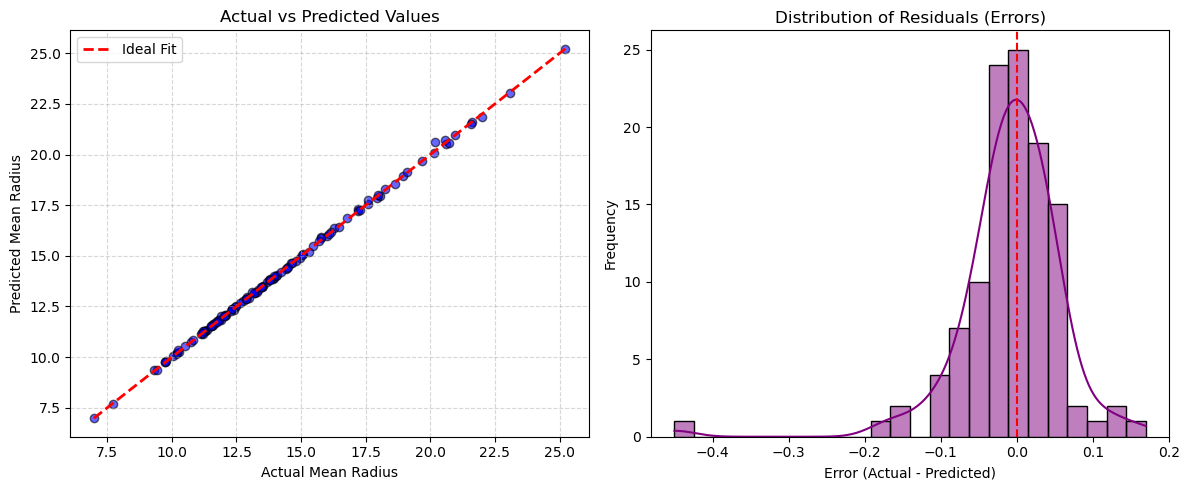

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# 1. Load Dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# 2. Define Regression Problem
# Target (y): 'mean radius'
# Features (X): All other columns
target_col = 'mean radius'
X = df.drop(columns=[target_col])
y = df[target_col]

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Regression Model (Simple Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Prediction
y_pred = model.predict(X_test)

# 6. Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Regression Performance (Linear Regression) ---")
print(f"Target Variable: {target_col}")
print(f"MSE (Mean Squared Error): {mse:.4f}")
print(f"R2 Score                : {r2:.4f}")

# 7. Visualization

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted Scatter Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, edgecolors='k')
# Plotting the ideal line y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Ideal Fit')
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Mean Radius')
plt.ylabel('Predicted Mean Radius')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Residuals Distribution
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()
